In [1]:
from data_handling import *
base_fp = '/trace/group/rounce/cvwilson/'

2018-05-01
2018-05-13
2018-05-25


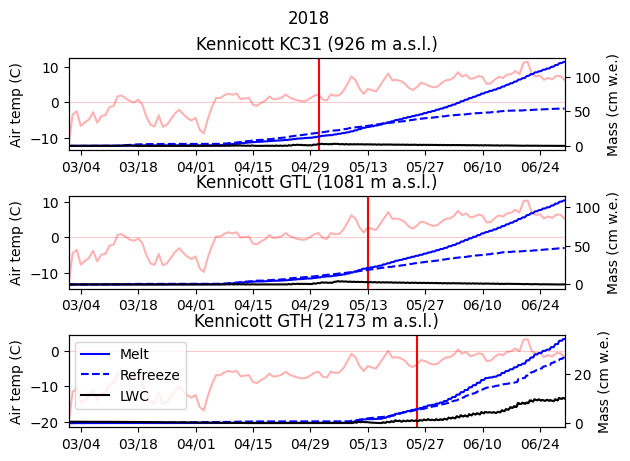

In [6]:
glacier = 'kennicott'
sites = ['KC31','GTL','GTH']
site_elev = {'KC31':926, 'GTL':1081, 'GTH':2173}

results = []

# print('PEBSI modeled cumulative melt and LWC at SAR-derived melt onset dates')
# print('   (averaged across descending scenes, 2018-2024)')

fig, axes = plt.subplots(3, gridspec_kw = {'hspace':0.5}) #  sharex='col') # , figsize=(15, 6))
for ax, site in zip(axes, sites):
    ds = xr.open_dataset(base_fp + f'Output/ddf/{glacier}{site}_2026_05_05_test_0.nc')
    sar = SnowMelt(glacier, site, 'Descending')

    melt_df = sar.sar_melt['med']
    cum_melt_list = []
    cum_rfz_list = []
    lwc_list = []
    ax2 = ax.twinx()
    
    for year in np.unique(melt_df.index.year)[1:2]:
        
        # Clip dataset to this year
        df_year = melt_df.loc[melt_df.index.year == year]
            
        # Get onset date from SAR
        sar_melt_onset = df_year.loc[df_year].index[0].strftime('%Y-%m-%d')
        print(sar_melt_onset)

        # Clip dataset up to this date and get cumulative melt
        period_start = pd.to_datetime(f'{year}-03-01')
        period_end = pd.to_datetime(f'{year}-06-30')
        ds_clipped = ds.sel(time=slice(period_start, period_end))
        summed_melt = ds_clipped.melt.sum().values
        summed_rfz = ds_clipped.refreeze.sum().values
        
        # Get LWC in m w.e.
        morning_lwc = (ds
                       .sel(time=pd.to_datetime(sar_melt_onset).replace(hour=8))
                       .layerwater.sum(dim='layer').values
        ) / 1000
        
        cum_melt_list.append(summed_melt)
        cum_rfz_list.append(summed_rfz)
        lwc_list.append(morning_lwc)

        time = ds_clipped.time.values
        daily = ds_clipped.airtemp.resample(time='d').mean()
        ax.plot(daily.time, daily.values, c='r', alpha=0.3,label='Air temperature')
        ax.axhline(0, c='r', alpha=0.3, linewidth=0.5)
        ax2.plot(time, ds_clipped.melt.cumsum()*100, c='blue',label='Melt')
        ax2.plot(time, ds_clipped.refreeze.cumsum()*100, c='blue',linestyle='--',label='Refreeze')
        ax2.plot(time, ds_clipped.layerwater.sum(dim='layer') / 10, c='k',label='LWC')
        ax.axvline(pd.to_datetime(sar_melt_onset), c='r',label='SAR melt onset')
        # ax2.axhline(0, c='k', alpha=0.3, linewidth=0.5)
        ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%m/%d'))
        ax.set_xlim(period_start, period_end)
        ax.set_xticks(pd.date_range(period_start, period_end, freq='2W'))
        elev = site_elev[site]
        ax.set_title(f'{glacier.capitalize()} {site} ({elev} m a.s.l.)')
        ax.set_ylabel('Air temp (C)')
        ax2.set_ylabel('Mass (cm w.e.)')

# axes[0].legend(bbox_to_anchor=(0.18, 0.72), loc='center')
ax2.legend()
fig.suptitle(str(year))
plt.show()

#     # Calculate means and standard deviations (converted to cm w.e.)
#     results.append({
#         'Site': site,
#         'Avg Cum Melt (cm)': np.nanmean(cum_melt_list) * 100,
#         'Melt StdDev': np.nanstd(cum_melt_list) * 100,
#         'Avg Cum Rfz (cm)': np.nanmean(cum_rfz_list) * 100,
#         'Rfz StdDev': np.nanstd(cum_rfz_list) * 100,
#         'Avg LWC (cm)': np.nanmean(lwc_list) * 100,
#         'LWC StdDev': np.nanstd(lwc_list) * 100
#     })

# # Create DataFrame for pretty printing
# summary_df = pd.DataFrame(results)

# # Option 1: Print using Pandas (simple)
# print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

# Option 2: Use tabulate if you have it installed for a "Prettier" look
# from tabulate import tabulate
# print(tabulate(summary_df, headers='keys', tablefmt='psql', floatfmt=".2f"))


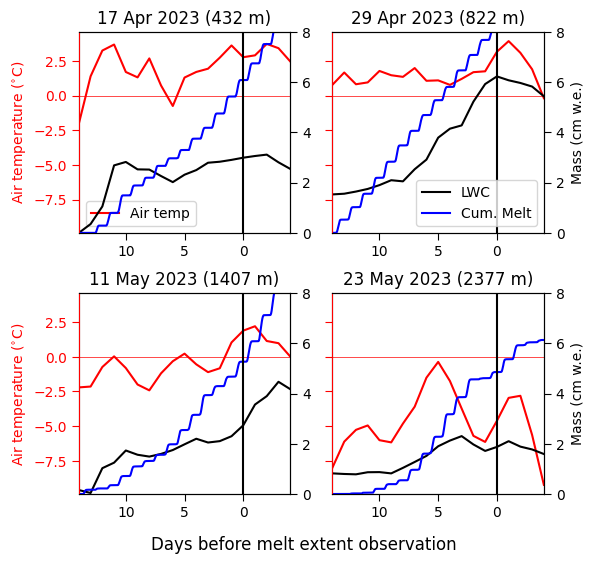

In [3]:
all_elevs = np.array(list(range(500, 2000, 100)) + list(range(2000, 4400, 500)))

by_elev = {}
for elev in all_elevs:
    ds = xr.open_dataset(f'/trace/group/rounce/cvwilson/Output/ddf/kennicottK{elev}_2026_05_06_sar_test_0.nc')
    by_elev[elev] = ds

s = SnowMelt('kennicott', 'GTH', 'Descending')
dfx = s.df_melt


for year in [2023]: # range(2019, 2025):
    df = dfx.loc[dfx.index.year == year]
    df = df[df.ne(df.shift()).any(axis=1)]
    df = df.loc[df.index.month.isin(range(4, 7))]
    df = df.loc[df.index != pd.to_datetime(f'{year}-04-05')]

    fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharey=True, gridspec_kw={'hspace':0.3})
    axes = axes.flatten()

    # cmap = plt.get_cmap('viridis')
    # norm = mpl.colors.Normalize(vmin=0, vmax=30)

    cum_PDDs = []
    nearest_elev_lwc = []
    i = -1
    for date in df.index:
        melt_elev = df.loc[date, 'melt_extent_elev_m']
        if np.min(np.abs(all_elevs - melt_elev)) < 200:
            nearest = all_elevs[np.argmin(np.abs(all_elevs - melt_elev))]
            ds = by_elev[nearest]
            lwc = (ds.sel(time=pd.to_datetime(date).replace(hour=8))
                        .layerwater.sum(dim='layer').values
            ) / 10 # from kg m-2 to cm w.e.

            nearest_elev_lwc.append(lwc)

            cum_ds = ds.sel(time=slice(date - pd.Timedelta(days=60), date))
            pdds = cum_ds.airtemp.resample(time='d').mean().clip(0)
            cum_PDDs.append(pdds.sum().values)
            
            i += 1
            if i > 3:
                continue
            
            ax = axes[i]

            leading = ds.sel(time=slice(date - pd.Timedelta(days=14), date + pd.Timedelta(days=4)))
            temp = leading.airtemp.resample(time='d').mean()
            
            x_days = (date - pd.to_datetime(temp.time.values)).days
            ax.plot(x_days, temp, c='r',label='Air temp')
            ax.axhline(0, c='r', linewidth=0.5)

            ax2 = ax.twinx()
            lwc_leading = leading.layerwater.sum(dim='layer').resample(time='d').max()/ 10 

            rfz_leading = leading.refreeze.cumsum() - leading.rainfall.cumsum()
            # rfz_leading = leading.layerrefreeze.where(leading.layertype == 0).sum(dim='layer').resample(time='d').max()/10 - leading.rainfall.resample(time='d').sum().cumsum()
            # print(rfz_leading.values, leading.rainfall.resample(time='d').sum().values)
            x = (date - pd.to_datetime(leading.time.values)).total_seconds() / 86400
            ax2.plot(x_days, lwc_leading, c='k', label='LWC')
            ax2.plot(x, leading.melt.cumsum() * 100, c='blue', label='Cum. Melt')
            ax2.axvline(0, c='k')
            # ax2.plot(x, rfz_leading, c='blue', linestyle='--', label='Refreeze')
            
            # ax.spines['left'].set_color('red')
            ax2.spines['left'].set_color('red')
            ax2.set_ylim(0, 8)
            # ax2.set_ylim(ax.get_ylim())
            date_str = date.strftime('%d %b %Y')
            ax.set_xlim(x[0], x[-1])
            ax.set_title(f'{date_str} ({int(melt_elev)} m)')
            ax.tick_params(length=5)
            ax.tick_params(axis='y', color='red', labelcolor='red')
            ax2.tick_params(length=5)
            if i in [1, 3]:
                ax2.set_ylabel('Mass (cm w.e.)')
            if i in [0,2]:
                ax.set_ylabel('Air temperature ($^{\circ}$C)', c='red')
            if i == 1:
                ax2.legend()

    axes[0].legend()

    fig.supxlabel('Days before melt extent observation')
    plt.savefig('/trace/group/rounce/cvwilson/figs/melt_extent_lwc.png', dpi=300, bbox_inches='tight')
    plt.show()
bins = np.arange(0, 7, 0.5)
# plt.hist(nearest_elev_lwc, bins=bins)
# plt.xlabel('LWC in snow at date of SAR melt extent observation (cm w.e.)')
# plt.ylabel('Count')
# plt.show()

# fig, ax = plt.subplots(figsize=(4, 4))
# df = pd.DataFrame({'PDDs':cum_PDDs, 'LWC':nearest_elev_lwc})
# corr = df.corr().iloc[0, 1]
# ax.scatter(cum_PDDs, nearest_elev_lwc, )
# ax.set_xlabel('Cumulative PDDs up to SAR acquisition date')
# ax.set_ylabel('LWC on SAR acquisition date')
# ax.text(0.98, 0.98, f'Pearson r: {corr:.3f}', transform=ax.transAxes, ha='right', va='top')
# plt.show()

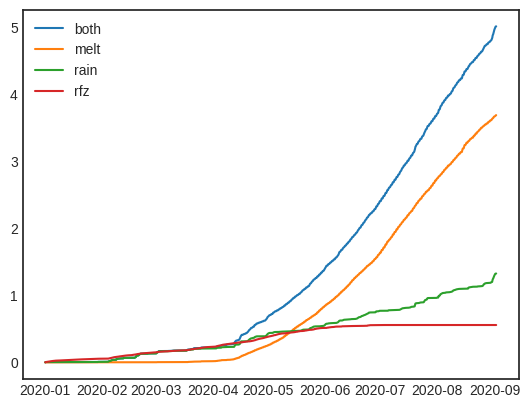

(<Figure size 500x170 with 2 Axes>, [<Axes: ylabel='Height above ice (m)'>])

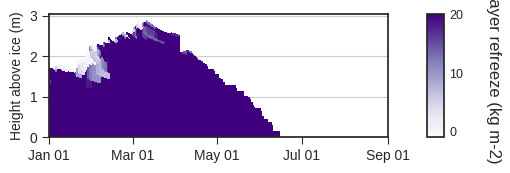

In [32]:
import sys 
sys.path.append('/trace/home/cvwilson/research/PEBSI/shop/plotting/')
from plotting_fxns import *
ds = by_elev[500]
a = ds.sel(time=slice('2020-01-01','2020-09-01'))
plt.plot(a.time, (a.rainfall + a.melt).cumsum(), label='both')
plt.plot(a.time, a.melt.cumsum(), label='melt')
plt.plot(a.time, a.rainfall.cumsum(),label='rain')

plt.plot(a.time, a.refreeze.cumsum(), label='rfz')
plt.legend()
plt.show()
visualize_layers(ds, pd.date_range('2020-01-01','2020-09-01'), ['layerrefreeze'], plot_firn=False)

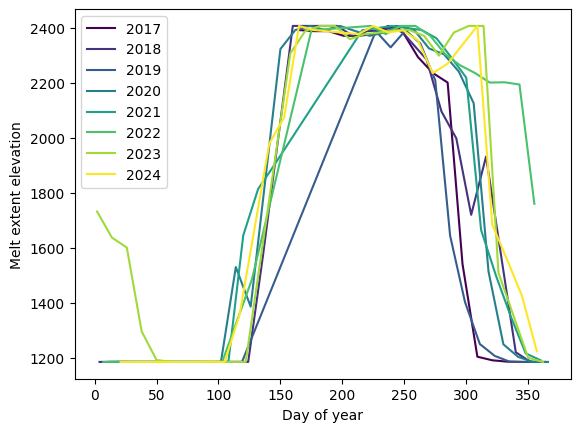

In [55]:
df = pd.read_csv('/trace/group/rounce/cvwilson/rs/sar/01.05299/01.05299_melt_extent_elev_percentile_160_379.csv')
df.index = pd.to_datetime(df['Unnamed: 0'])
df['doy'] = df.index.day_of_year 

cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=2017, vmax=2024)
for year in np.unique(df.index.year):
    a = df.loc[df.index.year == year]
    plt.plot(a.doy, a.melt_extent_elev_m, c=cmap(norm(year)),label=str(year))
plt.ylabel('Melt extent elevation')
plt.legend()
plt.xlabel('Day of year')
plt.show()